# PCA implementado do zero

**Tema:** Álgebra Linear e Otimização › Decomposições: SVD, Autovalores e PCA

PCA não é um algoritmo misterioso escondido dentro do `sklearn` — é a
decomposição espectral da covariância, ou (o jeito que se usa na prática) a
SVD dos dados centralizados. Este notebook implementa as duas vias, prova que
batem, e aplica o resultado a um dataset real de dígitos escritos à mão.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(3)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. PCA do zero, via covariância (a definição de livro-texto)

In [2]:
def pca_via_covariancia(X, n_componentes):
    media = X.mean(axis=0)
    Xc = X - media
    C = np.cov(Xc, rowvar=False)
    autoval, autovec = np.linalg.eigh(C)          # eigh: C é simétrica
    ordem = np.argsort(autoval)[::-1]              # eigh ordena crescente -> invertemos
    autoval, autovec = autoval[ordem], autovec[:, ordem]

    componentes = autovec[:, :n_componentes]
    scores = Xc @ componentes
    variancia_explicada = autoval[:n_componentes]
    return scores, componentes, variancia_explicada, media, autoval

## 2. PCA do zero, via SVD dos dados centralizados (o que se usa na prática)

In [3]:
def pca_via_svd(X, n_componentes):
    media = X.mean(axis=0)
    Xc = X - media
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)

    componentes = Vt[:n_componentes].T
    scores = (U[:, :n_componentes] * s[:n_componentes])  # = Xc @ componentes
    variancia_explicada = (s ** 2) / (len(X) - 1)
    return scores, componentes, variancia_explicada[:n_componentes], media, variancia_explicada

## 3. As duas vias batem?

Vamos testar em um dataset sintético 2D correlacionado, fácil de visualizar.

In [4]:
X_2d = rng.multivariate_normal(mean=[3, 5], cov=[[5.0, 3.5], [3.5, 3.0]], size=800)

scores_cov, comp_cov, var_cov, media_cov, _ = pca_via_covariancia(X_2d, n_componentes=2)
scores_svd, comp_svd, var_svd, media_svd, _ = pca_via_svd(X_2d, n_componentes=2)

print("variância explicada (via covariância):", var_cov)
print("variância explicada (via SVD)        :", var_svd)
print("\ncomponentes (via covariância):\n", comp_cov)
print("\ncomponentes (via SVD):\n", comp_svd)
print("\n(sinais de colunas podem diferir — direção da reta é a mesma, sentido é arbitrário)")

variância explicada (via covariância): [7.0734 0.3527]
variância explicada (via SVD)        : [7.0734 0.3527]

componentes (via covariância):
 [[-0.8011  0.5985]
 [-0.5985 -0.8011]]

componentes (via SVD):
 [[ 0.8011 -0.5985]
 [ 0.5985  0.8011]]

(sinais de colunas podem diferir — direção da reta é a mesma, sentido é arbitrário)


## 4. Visualizando os componentes principais sobre os dados

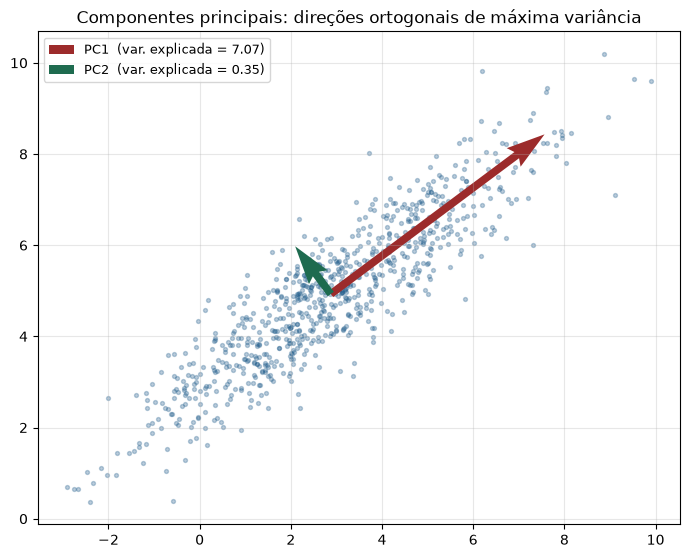

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=8, alpha=0.3, color=AZUL)
for i in range(2):
    v = comp_svd[:, i]
    escala = 2.2 * np.sqrt(var_svd[i])
    ax.quiver(*media_svd, *(escala * v), color=VERMELHO if i == 0 else VERDE,
              angles="xy", scale_units="xy", scale=1, width=0.012,
              label=f"PC{i + 1}  (var. explicada = {var_svd[i]:.2f})")
ax.set_aspect("equal")
ax.set_title("Componentes principais: direções ortogonais de máxima variância")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5. Comparando com `sklearn.decomposition.PCA`

O `sklearn` também usa SVD por baixo dos panos. A implementação do zero deve
bater com ele a menos de sinal.

In [6]:
pca_sklearn = PCA(n_components=2).fit(X_2d)
print("variância explicada (sklearn):", pca_sklearn.explained_variance_)
print("variância explicada (do zero):", var_svd)
print("\ncomponentes (sklearn):\n", pca_sklearn.components_)
print("\ncomponentes (do zero, transpostos p/ comparar):\n", comp_svd.T)

variância explicada (sklearn): [7.0734 0.3527]
variância explicada (do zero): [7.0734 0.3527]

componentes (sklearn):
 [[ 0.8011  0.5985]
 [-0.5985  0.8011]]

componentes (do zero, transpostos p/ comparar):
 [[ 0.8011  0.5985]
 [-0.5985  0.8011]]


## 6. Aplicando a dígitos escritos à mão: PCA como compressão de imagens

`load_digits` traz 1797 imagens 8x8 (64 pixels) de dígitos manuscritos — um
dataset pequeno e local, sem download. Cada imagem é um ponto em
$\mathbb{R}^{64}$; vamos ver quantas dimensões realmente carregam informação.

forma dos dados: (1797, 64)  (1797 imagens, 64 pixels cada)


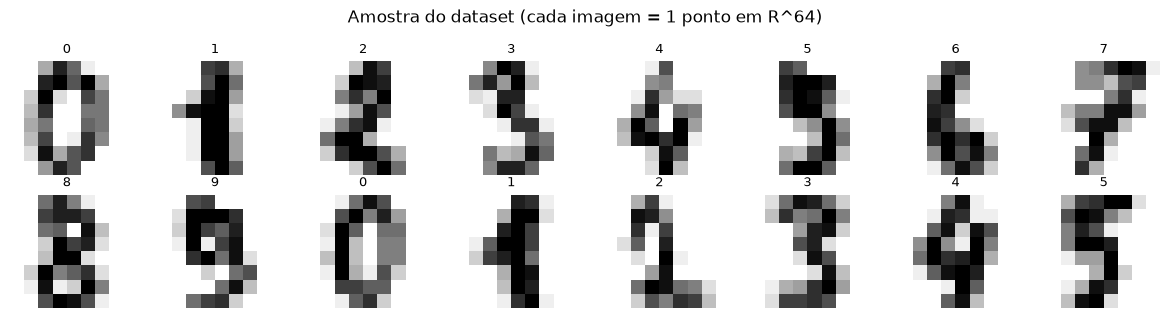

In [7]:
digitos = load_digits()
X_dig, y_dig = digitos.data, digitos.target
print(f"forma dos dados: {X_dig.shape}  (1797 imagens, 64 pixels cada)")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, rotulo in zip(axes.ravel(), X_dig, y_dig):
    ax.imshow(img.reshape(8, 8), cmap="gray_r")
    ax.set_title(str(rotulo), fontsize=9)
    ax.axis("off")
plt.suptitle("Amostra do dataset (cada imagem = 1 ponto em R^64)")
plt.tight_layout(); plt.show()

### Variância explicada por número de componentes

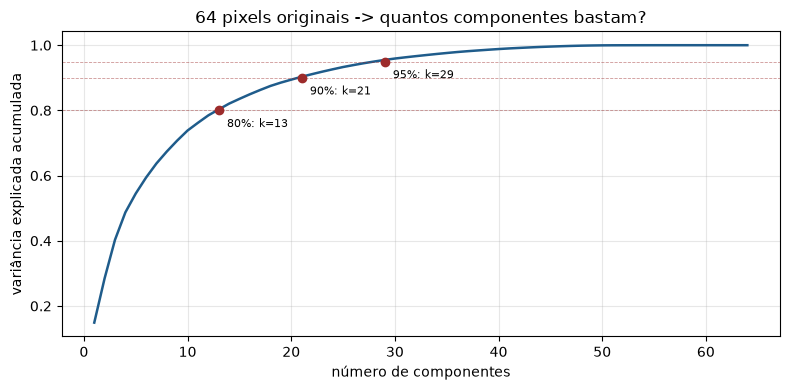

64 dimensões originais -> 21 componentes bastam para 90% da variância.


In [8]:
_, _, _, _, todos_autoval = pca_via_svd(X_dig, n_componentes=X_dig.shape[1])
energia_acumulada = np.cumsum(todos_autoval) / np.sum(todos_autoval)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(energia_acumulada) + 1), energia_acumulada, color=AZUL, lw=1.8)
for alvo in [0.80, 0.90, 0.95]:
    k = np.searchsorted(energia_acumulada, alvo) + 1
    ax.axhline(alvo, color=VERMELHO, lw=0.6, ls="--", alpha=0.5)
    ax.scatter([k], [alvo], color=VERMELHO, zorder=3)
    ax.annotate(f"{alvo:.0%}: k={k}", (k, alvo), textcoords="offset points",
                xytext=(6, -12), fontsize=8)
ax.set_xlabel("número de componentes"); ax.set_ylabel("variância explicada acumulada")
ax.set_title("64 pixels originais -> quantos componentes bastam?")
plt.tight_layout(); plt.show()

print(f"64 dimensões originais -> {np.searchsorted(energia_acumulada, 0.90) + 1} "
      f"componentes bastam para 90% da variância.")

### Reconstrução: quanto uma imagem se degrada ao comprimir

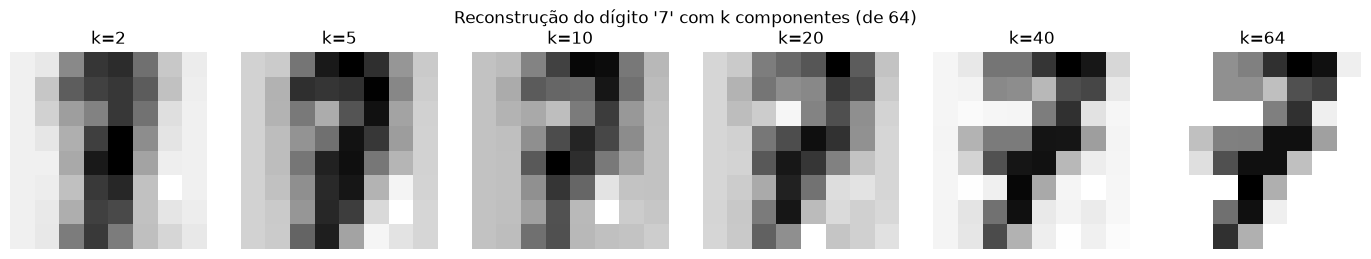

In [9]:
scores_dig, comp_dig, _, media_dig, _ = pca_via_svd(X_dig, n_componentes=64)

fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
idx = 7  # uma imagem qualquer do dataset
for ax, k in zip(axes, [2, 5, 10, 20, 40, 64]):
    reconstruida = media_dig + scores_dig[idx, :k] @ comp_dig[:, :k].T
    ax.imshow(reconstruida.reshape(8, 8), cmap="gray_r")
    ax.set_title(f"k={k}")
    ax.axis("off")
plt.suptitle(f"Reconstrução do dígito '{y_dig[idx]}' com k componentes (de 64)")
plt.tight_layout(); plt.show()

## 7. Por que padronizar antes de aplicar PCA em features de escalas diferentes

Nos pixels dos dígitos, todas as "features" estão na mesma escala (0 a 16), e
padronizar não muda a conclusão qualitativa. Mas em dados tabulares comuns,
ignorar a escala é um erro sério: uma feature em milhares de reais domina a
variância só por causa da unidade, não da importância.

In [10]:
n = 500
renda = rng.normal(6000, 2500, n)            # escala: milhares
idade = rng.normal(35, 10, n)                # escala: dezenas
tempo_de_casa_meses = rng.normal(24, 12, n)  # escala: dezenas

X_misto = np.column_stack([renda, idade, tempo_de_casa_meses])

_, _, var_sem_padronizar, _, _ = pca_via_svd(X_misto, n_componentes=3)
X_padronizado = StandardScaler().fit_transform(X_misto)
_, comp_padronizado, var_com_padronizar, _, _ = pca_via_svd(X_padronizado, n_componentes=3)

print("variância de cada feature bruta:", X_misto.var(axis=0, ddof=1).round(1))
print(f"\nvariância explicada pelo 1º componente (SEM padronizar): "
      f"{var_sem_padronizar[0] / var_sem_padronizar.sum():.1%}")
print("  -> quase toda a 'variância explicada' é só a escala da renda, não estrutura real.")

print(f"\nvariância explicada pelo 1º componente (COM padronizar): "
      f"{var_com_padronizar[0] / var_com_padronizar.sum():.1%}")
print("  -> mais próximo de 1/3 cada, porque as três variáveis aqui são independentes"
      " por construção.")

variância de cada feature bruta: [6676751.3     106.6     159.5]

variância explicada pelo 1º componente (SEM padronizar): 100.0%
  -> quase toda a 'variância explicada' é só a escala da renda, não estrutura real.

variância explicada pelo 1º componente (COM padronizar): 38.3%
  -> mais próximo de 1/3 cada, porque as três variáveis aqui são independentes por construção.


## O que levar deste notebook

- PCA via covariância e via SVD dos dados centralizados são **matematicamente
  idênticos** — a segunda via é a usada na prática por estabilidade numérica.
- A implementação do zero bate com `sklearn.decomposition.PCA` a menos do
  sinal arbitrário dos componentes.
- Poucos componentes capturam a maior parte da variância em dados de imagem
  — a mesma lógica de Eckart-Young do notebook anterior.
- **Padronizar antes de PCA não é opcional** quando as features têm escalas
  diferentes: sem isso, o "primeiro componente principal" pode ser só a
  feature de maior variância numérica, travestida de estrutura latente.

→ Próximo: o notebook de **exercícios** do módulo.